### Deep learning model training.


In [2]:
import time
import torch
import random
import numpy as np 
import pandas as pd 
import torch.nn as nn
from glob import glob
from notebooks import config
import matplotlib.pyplot as plt
from pyrsimg import imsShow
from utils.utils import read_scenes
from utils.metrics import oa_binary, miou_binary
from utils.data_loader import SceneArraySet, PatchPathSet
from utils.data_loader import GaussianNoise
from torchvision.transforms import v2
from model import unet, deeplabv3plus, deeplabv3plus_mobilev2


In [3]:
patch_size = 512  ## patch size setting
patch_resize = None  ## patch resize setting
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
print(f'train scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali patch {patch_size}: {len(paths_valset)}')


train scenes: 171
vali patch 512: 208


### dataset loading

In [4]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, paths_truth_tra) 
scene_truth_ls =  list(zip(scenes_arr, truths_arr))
scene_truth_ls = [np.concatenate([scene, truth[:, :, np.newaxis]], axis=-1) 
                             for scene, truth in scene_truth_ls] 


In [5]:
transforms_tra = v2.Compose([
      v2.ToImage(),
      v2.RandomCrop(size=(patch_size, patch_size), padding = 100, fill=0),
      v2.RandomApply([v2.RandomRotation(degrees=180)], p=0.3),
      v2.RandomHorizontalFlip(p=0.3),
      v2.RandomVerticalFlip(p=0.3),
      GaussianNoise(mean=0, sigma_max=0.1, p=0.3)    
       ])
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])



In [6]:
tra_dset = SceneArraySet(scene_truth_list = scene_truth_ls, 
                          transforms = transforms_tra)
val_dset = PatchPathSet(paths_valset=paths_valset, 
                          transforms=transforms_val)
### Create DataLoader
tra_loader = torch.utils.data.DataLoader(tra_dset, 
                                         batch_size=4, 
                                         shuffle=True, 
                                         num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dset, 
                                         batch_size=4,
                                         num_workers=5) 


#### Model training

In [7]:
### check model
model = unet(num_bands=6)
# model = deeplabv3plus(num_bands=6)
# model = deeplabv3plus_mobilev2(num_bands=6)


In [8]:
input_tensor = torch.randn(2, 6, 512, 512)  
output = model(input_tensor) 
print(output.shape)


torch.Size([2, 1, 512, 512])


In [9]:
### create loss and optimizer
loss_bce = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, \
                                      mode='min', 
                                      factor=0.5, 
                                      patience=10,
                                      min_lr=1e-5)


In [10]:

'''------train step------'''
def train_step(model, loss_fn, optimizer, x, y):
    optimizer.zero_grad()
    pred = model(x)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    miou = miou_binary(pred=pred, truth=y)
    oa = oa_binary(pred=pred, truth=y)
    return loss, miou, oa

'''------validation step------'''
def val_step(model, loss_fn, x, y):
    model.eval()
    with torch.no_grad():
        pred = model(x)
        loss = loss_fn(pred, y)
    miou = miou_binary(pred=pred, truth=y)
    oa = oa_binary(pred=pred, truth=y)
    return loss, miou, oa

'''------train loops------'''
def train_loops(model, loss_fn, optimizer, 
                    tra_loader, val_loader,                     
                    epoches, device, 
                    lr_scheduler=None):
    tra_loss_loops, tra_miou_loops, tra_oa_loops = [], [], []
    val_loss_loops, val_miou_loops, val_oa_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    epoch_record = []
    for epoch in range(epoches):
        start = time.time()
        tra_loss, val_loss = 0, 0
        tra_miou, val_miou = 0, 0
        tra_oa, val_oa = 0, 0
        '''-----1. train the model-----'''
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss, miou, oa = train_step(model=model, loss_fn=loss_fn, 
                                            optimizer=optimizer, 
                                            x=x_batch, 
                                            y=y_batch)
            tra_loss += loss.item()
            tra_miou += miou.item()
            tra_oa += oa.item()
        if lr_scheduler:
          lr_scheduler.step(tra_loss)    ## if using ReduceLROnPlateau
        '''----- 2. validate the model: time consuming -----'''
        if epoch % 3 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                loss, miou, oa = val_step(model=model, 
                                            loss_fn=loss_fn, 
                                            x=x_batch, 
                                            y=y_batch, 
                                            )
                val_loss += loss.item()
                val_miou += miou.item()
                val_oa += oa.item()
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            val_loss = val_loss/size_val_loader
            val_miou = val_miou/size_val_loader
            val_oa = val_oa/size_val_loader
            tra_loss_loops.append(tra_loss); tra_miou_loops.append(tra_miou); tra_oa_loops.append(tra_oa)
            val_loss_loops.append(val_loss); val_miou_loops.append(val_miou); val_oa_loops.append(val_oa)
            epoch_record.append(epoch)
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, '
                    f'val-> Loss:{val_loss:.3f},Oa:{val_oa:.3f}, Miou:{val_miou:.3f},time:{time.time()-start:.1f}s')
        else: 
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, \
                                time:{time.time()-start:.1f}s')

        '''----- 3. show the result -----'''
        if epoch%20 == 0:
            model.eval()
            sam_index = random.randrange(len(val_dset))
            patch_val, truth_val = val_dset[sam_index]
            patch_val, truth_val = patch_val.unsqueeze(0).to(device), truth_val.to(device)
            pred_val = model(patch_val) 
            ## convert to numpy and plot
            patch_val = patch_val[0].to('cpu').detach().numpy().transpose(1,2,0)            
            pred_val = pred_val[0].to('cpu').detach().numpy()
            truth_val = truth_val.to('cpu').detach().numpy()
            imsShow([patch_val, pred_val, truth_val], 
                    clip_list = (2,0,0),
                    img_name_list=['patch', 'pred', 'truth'], 
                    color_bands_list=([3,2,2], 0, 0),                    
                    figsize=(9, 2.5))
            plt.tight_layout() 
            plt.show()
    metrics = {'epoch':epoch_record,'tra_loss':tra_loss_loops, 'tra_miou':tra_miou_loops, 'tra_oa': tra_oa_loops, 
                'val_loss': val_loss_loops, 'val_miou': val_miou_loops, 'val_oa': val_oa_loops}
    return metrics 


Ep0: tra-> Loss:0.191,Oa:0.901,Miou:0.794, val-> Loss:0.208,Oa:0.895, Miou:0.799,time:5.4s


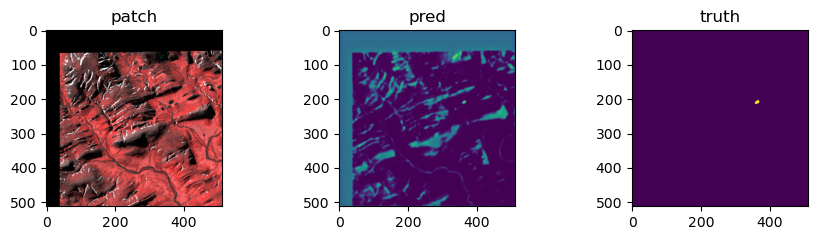

Ep1: tra-> Loss:0.145,Oa:0.922,Miou:0.808,                                 time:3.1s
Ep2: tra-> Loss:0.128,Oa:0.923,Miou:0.828,                                 time:3.1s


In [ ]:
device = torch.device('cuda:0') 
metrics = train_loops(model=model, 
                epoches=300,  
                loss_fn=loss_bce,  
                optimizer=optimizer,  
                tra_loader=tra_loader,  
                val_loader=val_loader,  
                lr_scheduler=lr_scheduler,  
                device=device)  


In [ ]:
# model saving 
model_name = 'unet' 
path_save = f'model/trained/seg_models/{model_name}_weights.pth'
torch.save(model.state_dict(), path_save)     ## save weights of the trained model 
# # model.load_state_dict(torch.load(path_save, weights_only=True))  ## load the weights of the trained model
# # ## metrics saving
path_metrics = f'model/trained/seg_models/{model_name}_metrics.csv'    
# path_metrics = f'model/trained/patch_{patch_size}/{model_name}_metrics_1.csv'    
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(path_metrics, index=False, sep=',')
